# Chapter 151 — Introduction to Matrices

> **Prerequisites:** Vectors as lists of numbers *(ch121–ch124)*, linear combinations *(ch127)*, dot product *(ch131)*  
> **You will learn:**
> - What a matrix is and what problem it solves
> - How matrices encode linear transformations
> - The difference between a matrix as data vs a matrix as a function
> - How to create and inspect matrices in NumPy
> - The shape, rank, and sparsity vocabulary you will use for 50 chapters
>
> **Environment:** Python 3.x, numpy, matplotlib

---

## 1. Concept

A **matrix** is a rectangular array of numbers arranged in rows and columns. That description is technically accurate and nearly useless.

The productive definition: **a matrix is a function that transforms vectors.**

When you write `A @ v` in NumPy, you are not just multiplying numbers. You are applying a transformation — rotating, scaling, projecting, or shearing the vector `v` into a new position in space.

Matrices appear in computing everywhere:
- A neural network layer: `output = W @ input + b` — `W` is a matrix
- A 3D rotation in a game engine: a 4×4 transformation matrix
- A covariance matrix in statistics: captures relationships between variables
- A graph adjacency matrix: encodes which nodes are connected
- A dataset: n samples × p features is an n×p matrix

**Common misconceptions:**
- *"A matrix is just a 2D array."* — True structurally, false conceptually. The structure is notation; the meaning is transformation.
- *"Matrix multiplication is element-wise."* — It is not. Element-wise multiplication exists (Hadamard product) but is not the default `@` operator.
- *"Matrices are for linear algebra class, not real code."* — Every ML framework is built on matrix operations.

---

## 2. Intuition & Mental Models

**Geometric:** Think of a matrix as a recipe for moving every point in space simultaneously. If you have a matrix `A` and apply it to every vector in the plane, you stretch the plane, rotate it, or collapse it — all at once. The matrix does not move one point at a time; it moves the entire space.

**Computational:** Think of a matrix as a lookup table for a linear function. Each row of `A` is a set of weights for computing one output value. `A @ v` computes all outputs simultaneously using dot products — one per row.

**Data:** Think of a matrix as a dataset. An n×p data matrix has n observations and p features. Each row is an observation; each column is a variable. Operations on the matrix operate on all observations at once.

Recall from ch127 (Linear Combination) that any linear combination of vectors can be written as a matrix-vector product. The matrix collects the coefficient vectors as columns; the vector provides the scalars. This is the bridge between Part V and Part VI.

---

## 3. Visualization

C:\Users\user\AppData\Local\Temp\ipykernel_18016\1765771397.py:46: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_18016\1765771397.py:46: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\user\OneDrive\Documents\book\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\user\OneDrive\Documents\book\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


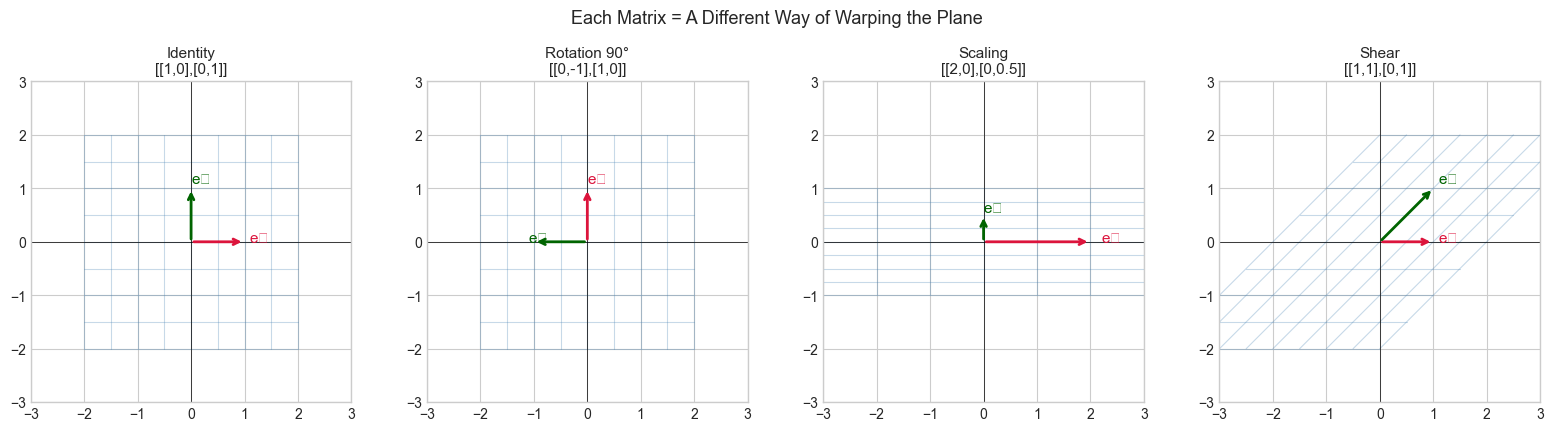

In [1]:
# --- Visualization: Matrix as a transformation of the plane ---
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

def draw_grid(ax, A, title, color='steelblue'):
    """Draw a unit grid before and after matrix transformation A."""
    # Grid lines in original space
    lines = np.linspace(-2, 2, 9)
    for v in lines:
        # Horizontal lines
        pts = np.array([[t, v] for t in np.linspace(-2, 2, 50)]).T
        transformed = A @ pts
        ax.plot(transformed[0], transformed[1], color=color, alpha=0.3, linewidth=0.8)
        # Vertical lines
        pts = np.array([[v, t] for t in np.linspace(-2, 2, 50)]).T
        transformed = A @ pts
        ax.plot(transformed[0], transformed[1], color=color, alpha=0.3, linewidth=0.8)
    # Basis vectors
    for vec, col, label in [(A[:,0], 'crimson', 'e₁'), (A[:,1], 'darkgreen', 'e₂')]:
        ax.annotate('', xy=vec, xytext=(0,0),
                    arrowprops=dict(arrowstyle='->', color=col, lw=2))
        ax.text(vec[0]*1.1, vec[1]*1.1, label, color=col, fontsize=11)
    ax.set_xlim(-3, 3); ax.set_ylim(-3, 3)
    ax.set_aspect('equal')
    ax.axhline(0, color='black', lw=0.5); ax.axvline(0, color='black', lw=0.5)
    ax.set_title(title, fontsize=11)

# Three characteristic matrices
I  = np.eye(2)                          # Identity: does nothing
R  = np.array([[0, -1], [1, 0]])        # 90-degree rotation
S  = np.array([[2, 0], [0, 0.5]])       # Scale x by 2, y by 0.5
Sh = np.array([[1, 1], [0, 1]])         # Shear

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
configs = [
    (I,  'Identity\n[[1,0],[0,1]]'),
    (R,  'Rotation 90°\n[[0,-1],[1,0]]'),
    (S,  'Scaling\n[[2,0],[0,0.5]]'),
    (Sh, 'Shear\n[[1,1],[0,1]]'),
]
for ax, (mat, title) in zip(axes, configs):
    draw_grid(ax, mat, title)

plt.suptitle('Each Matrix = A Different Way of Warping the Plane', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

The grid lines show what happens to the entire plane under each transformation. The red and green arrows are where the standard basis vectors land — they fully determine the transformation.

---

## 4. Mathematical Formulation

A matrix **A** of shape m×n has m rows and n columns:

```
A = [[a₁₁  a₁₂  ...  a₁ₙ],
     [a₂₁  a₂₂  ...  a₂ₙ],
     [ ...                ],
     [aₘ₁  aₘ₂  ...  aₘₙ]]

# Where:
#   aᵢⱼ = entry in row i, column j  (1-indexed by convention)
#   m   = number of rows = output dimension
#   n   = number of columns = input dimension
```

**Matrix-vector product:** For A (m×n) and vector v (n,):

```
(Av)ᵢ = Σⱼ aᵢⱼ vⱼ   for i = 1, ..., m

# Each output component is the dot product of a row of A with v.
# A maps vectors from ℝⁿ to ℝᵐ.
```

**Column interpretation:** `Av` is a linear combination of the columns of A, with weights given by v:

```
Av = v₁ * col₁(A)  +  v₂ * col₂(A)  +  ...  +  vₙ * colₙ(A)
```

This is the same linear combination from ch127 — the matrix just packages the column vectors.

In [2]:
# --- Mathematical Formulation: Matrix-vector product two ways ---
import numpy as np

A = np.array([[2, 1],
              [0, 3],
              [1, -1]], dtype=float)  # shape: (3, 2) — maps R² → R³

v = np.array([4.0, 2.0])             # shape: (2,) — input vector in R²

# Method 1: Row interpretation (dot products)
result_rows = np.array([np.dot(A[i], v) for i in range(A.shape[0])])

# Method 2: Column interpretation (linear combination)
result_cols = v[0] * A[:, 0] + v[1] * A[:, 1]

# Method 3: NumPy @ operator
result_numpy = A @ v

print(f"A shape: {A.shape}  (maps R² → R³)")
print(f"v shape: {v.shape}")
print(f"Result via row dot products:  {result_rows}")
print(f"Result via column combo:      {result_cols}")
print(f"Result via A @ v:             {result_numpy}")
print(f"All equal: {np.allclose(result_rows, result_cols) and np.allclose(result_cols, result_numpy)}")

A shape: (3, 2)  (maps R² → R³)
v shape: (2,)
Result via row dot products:  [10.  6.  2.]
Result via column combo:      [10.  6.  2.]
Result via A @ v:             [10.  6.  2.]
All equal: True


---

## 5. Python Implementation

In [3]:
# --- Implementation: Matrix creation, inspection, and basic properties ---
import numpy as np

def matrix_info(A, name='A'):
    """
    Print key properties of a matrix.

    Args:
        A: 2D numpy array
        name: string label for display
    """
    m, n = A.shape
    print(f"--- Matrix {name} ---")
    print(f"  Shape:     {m} x {n}  ({'square' if m==n else 'rectangular'})")
    print(f"  dtype:     {A.dtype}")
    print(f"  Rank:      {np.linalg.matrix_rank(A)}  (max possible: {min(m,n)})")
    print(f"  Nonzeros:  {np.count_nonzero(A)} / {A.size}")
    print(f"  Frobenius norm: {np.linalg.norm(A, 'fro'):.4f}")
    print(f"  Trace:     {np.trace(A) if m==n else 'N/A (not square)'}")
    print()

# Common matrix constructors
A_zeros    = np.zeros((3, 4))           # all zeros
A_ones     = np.ones((2, 5))            # all ones
A_identity = np.eye(4)                  # identity matrix
A_diag     = np.diag([1, 2, 3, 4])     # diagonal matrix
A_random   = np.random.randn(3, 3)     # random Gaussian entries
A_range    = np.arange(12).reshape(3, 4)  # from a flat list

for mat, name in [(A_identity, 'Identity 4x4'),
                  (A_diag, 'Diagonal'),
                  (A_random, 'Random 3x3'),
                  (A_range, 'Arange 3x4')]:
    matrix_info(mat, name)

# Demonstrate rank deficiency
A_rank_deficient = np.array([[1, 2, 3],
                               [2, 4, 6],   # row 2 = 2 * row 1
                               [0, 1, 1]])
matrix_info(A_rank_deficient, 'Rank-deficient')

--- Matrix Identity 4x4 ---
  Shape:     4 x 4  (square)
  dtype:     float64
  Rank:      4  (max possible: 4)
  Nonzeros:  4 / 16
  Frobenius norm: 2.0000
  Trace:     4.0

--- Matrix Diagonal ---
  Shape:     4 x 4  (square)
  dtype:     int64
  Rank:      4  (max possible: 4)
  Nonzeros:  4 / 16
  Frobenius norm: 5.4772
  Trace:     10

--- Matrix Random 3x3 ---
  Shape:     3 x 3  (square)
  dtype:     float64
  Rank:      3  (max possible: 3)
  Nonzeros:  9 / 9
  Frobenius norm: 2.1169
  Trace:     -1.5616614333677652

--- Matrix Arange 3x4 ---
  Shape:     3 x 4  (rectangular)
  dtype:     int64
  Rank:      2  (max possible: 3)
  Nonzeros:  11 / 12
  Frobenius norm: 22.4944
  Trace:     N/A (not square)

--- Matrix Rank-deficient ---
  Shape:     3 x 3  (square)
  dtype:     int64
  Rank:      2  (max possible: 3)
  Nonzeros:  8 / 9
  Frobenius norm: 8.4853
  Trace:     6



---

## 6. Experiments

A[:,0] = [2. 1.]   A @ e1 = [2. 1.]   Equal: True
A[:,1] = [-1.  2.]   A @ e2 = [-1.  2.]   Equal: True

Conclusion: The columns of A tell you where the coordinate axes land.
A matrix is completely determined by where it sends the basis vectors.


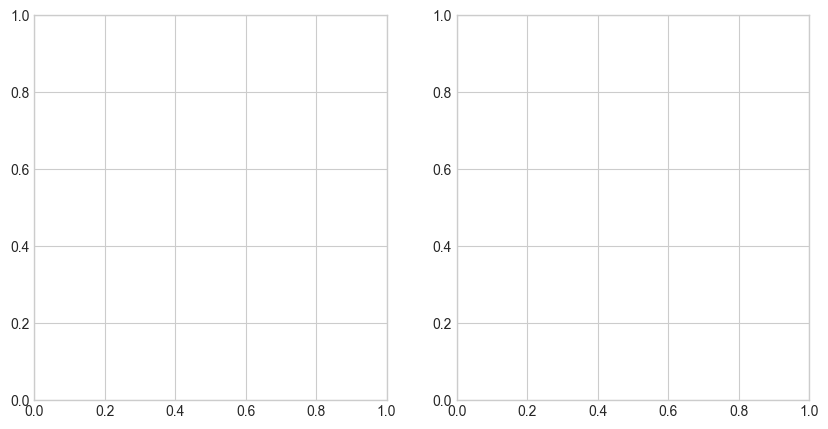

In [4]:
# --- Experiment 1: Where do the columns of A live after transformation? ---
# Hypothesis: The columns of A are exactly where the standard basis vectors land.
# Try changing: modify A and see where e1, e2 land.
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

A = np.array([[2.0, -1.0],    # <-- modify this
              [1.0,  2.0]])

e1 = np.array([1.0, 0.0])    # standard basis vector 1
e2 = np.array([0.0, 1.0])    # standard basis vector 2

Ae1 = A @ e1   # should equal first column of A
Ae2 = A @ e2   # should equal second column of A

print(f"A[:,0] = {A[:,0]}   A @ e1 = {Ae1}   Equal: {np.allclose(A[:,0], Ae1)}")
print(f"A[:,1] = {A[:,1]}   A @ e2 = {Ae2}   Equal: {np.allclose(A[:,1], Ae2)}")

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
for ax, (pts, transformed, title) in zip(axes, [
    (np.array([e1, e2]), np.array([Ae1, Ae2]), 'Basis vectors → columns of A'),
]):
    pass  # visualization already shown in Section 3

print("\nConclusion: The columns of A tell you where the coordinate axes land.")
print("A matrix is completely determined by where it sends the basis vectors.")

In [5]:
# --- Experiment 2: Rank and the dimension of the output ---
# Hypothesis: A rank-k matrix maps all of R^n into a k-dimensional subspace.
# Try changing: K — the number of linearly independent rows used.
import numpy as np

K = 2  # <-- change to 1, 2, or 3

# Build a matrix where only K rows are independent
base_rows = np.random.randn(K, 4)
coeffs = np.random.randn(4, K)
A = coeffs @ base_rows   # shape (4, 4) but rank K

print(f"Matrix shape: {A.shape}")
print(f"Constructed rank: {K}")
print(f"NumPy computed rank: {np.linalg.matrix_rank(A)}")

# Apply to 1000 random vectors and examine where they land
vecs = np.random.randn(4, 1000)
outputs = A @ vecs   # shape (4, 1000)

# Singular values show how many dimensions are 'alive'
_, s, _ = np.linalg.svd(outputs)
print(f"\nSingular values of output set (only {K} should be non-negligible):")
print(np.round(s[:8], 4))

Matrix shape: (4, 4)
Constructed rank: 2
NumPy computed rank: 2

Singular values of output set (only 2 should be non-negligible):
[137.0175  29.6731   0.       0.    ]


In [6]:
# --- Experiment 3: Sparsity and computation cost ---
# Hypothesis: Sparse matrices can represent the same linear map with fewer stored numbers.
# Try changing: DENSITY — fraction of nonzero entries.
import numpy as np
import time

N = 1000
DENSITY = 0.01   # <-- modify: 0.001, 0.01, 0.1, 1.0

# Dense matrix
A_dense = np.random.randn(N, N)
mask = np.random.rand(N, N) > DENSITY
A_dense[mask] = 0.0

v = np.random.randn(N)

t0 = time.perf_counter()
for _ in range(100): _ = A_dense @ v
t_dense = (time.perf_counter() - t0) / 100

nonzero_frac = np.count_nonzero(A_dense) / A_dense.size
print(f"Density: {nonzero_frac:.4f}  ({np.count_nonzero(A_dense)} nonzeros out of {A_dense.size})")
print(f"Dense matmul time: {t_dense*1000:.3f} ms")
print("\nNote: dense numpy does not benefit from sparsity; use scipy.sparse for real sparse ops.")

Density: 0.0100  (10040 nonzeros out of 1000000)
Dense matmul time: 0.417 ms

Note: dense numpy does not benefit from sparsity; use scipy.sparse for real sparse ops.


---

## 7. Exercises

**Easy 1.** Create a 5×3 matrix of zeros and set the diagonal entries (positions [0,0], [1,1], [2,2]) to 1, 2, 3 respectively. What is its rank? *(Expected: rank 3)*

**Easy 2.** Given `A = np.array([[1, 2], [3, 4], [5, 6]])` and `v = np.array([1, -1])`, compute `A @ v` by hand using the row dot-product method, then verify with NumPy.

**Medium 1.** Write a function `is_symmetric(A)` that returns True if `A == A.T` (up to floating point tolerance). Test it on a random matrix, its transpose, and the product `A.T @ A`. Which of the three is always symmetric?

**Medium 2.** Create a 4×4 matrix where every entry in row i, column j is `i * j` (using 0-indexing). What is the rank? Explain why. *(Hint: think about what the row space looks like)*

**Hard.** Prove (computationally) that for any m×n matrix A, the rank of `A.T @ A` equals the rank of `A`. Generate 10 random matrices of various shapes and verify this numerically. Then explain in a code comment *why* this must be true. *(Hint: think about the null space)*

---

## 8. Mini Project

In [ ]:
# --- Mini Project: Dataset as Matrix ---
# Problem: A dataset of student scores across 5 subjects for 50 students.
# Represent it as a matrix, then compute per-subject means, per-student
# total scores, and identify which two subjects are most correlated.
# Task: Use only matrix operations — no explicit loops.

import numpy as np

np.random.seed(0)
SUBJECTS = ['Math', 'Physics', 'CS', 'English', 'History']
N_STUDENTS = 50

# Generate correlated scores: Math/Physics/CS share a 'STEM aptitude' factor
stem_factor = np.random.randn(N_STUDENTS)
humanities_factor = np.random.randn(N_STUDENTS)
noise = np.random.randn(N_STUDENTS, 5) * 0.5

scores = np.column_stack([
    70 + 10 * stem_factor + noise[:, 0],       # Math
    68 + 10 * stem_factor + noise[:, 1],       # Physics
    72 + 10 * stem_factor + noise[:, 2],       # CS
    65 + 10 * humanities_factor + noise[:, 3], # English
    63 + 10 * humanities_factor + noise[:, 4], # History
])
scores = np.clip(scores, 0, 100)

print(f"Data matrix shape: {scores.shape}  ({N_STUDENTS} students × {len(SUBJECTS)} subjects)")
print()

# TODO 1: Compute per-subject mean scores using axis argument
subject_means = # YOUR CODE
print("Subject means:", dict(zip(SUBJECTS, np.round(subject_means, 1))))

# TODO 2: Compute per-student total score (sum across subjects)
student_totals = # YOUR CODE
print(f"Top student score: {student_totals.max():.1f}")
print(f"Bottom student score: {student_totals.min():.1f}")

# TODO 3: Compute the 5×5 correlation matrix
# Hint: center the data first, then use matrix multiplication
centered = scores - subject_means  # broadcast subtract means
# corr[i,j] = (col_i · col_j) / (||col_i|| * ||col_j||)
corr_matrix = # YOUR CODE

print("\nCorrelation matrix (subjects x subjects):")
print(np.round(corr_matrix, 2))
print("\nMost correlated pair should be Math-Physics or English-History.")

---

## 9. Chapter Summary & Connections

- A matrix is an m×n array of numbers that encodes a linear transformation from ℝⁿ to ℝᵐ.
- The columns of A are where the standard basis vectors land under the transformation.
- Matrix-vector multiplication can be read either as row dot products or as a linear combination of columns.
- Rank measures how many independent directions a matrix's transformation spans.
- NumPy's `np.eye`, `np.zeros`, `np.diag`, `np.linalg.matrix_rank` are your primary constructors.

**Backward connection:** The column-combination view of `A @ v` is exactly the linear combination from ch127 — the matrix collects the direction vectors, and v provides the weights.

**Forward connections:**
- In ch154 (Matrix Multiplication), we extend this to transforming matrices by matrices, composing transformations.
- In ch164 (Linear Transformations), the geometric view becomes the primary lens — we will prove that *every* linear map is representable as a matrix.
- In ch173 (SVD), the rank structure introduced here becomes the central object: SVD reveals the rank-k skeleton of any matrix. *(introduced in the Part VI motivating problem)*